Random Slope: 0.8535002881996945
Random Intercept: 0.8679579889598403

Linear Least Squares Fit
MSE: 0.08284039930996845
R^2: 0.4190019938254145

Cubic Polynomial Fit
MSE: 0.07918691927391289
R^2: 0.4446255378236085

Polynomial model is the better fit


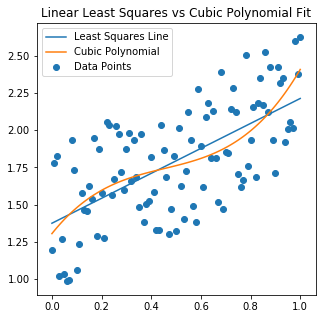


Testing Polynomial Degrees to show underfitting and overfitting

Polynomial Degree: 1
MSE: 0.08284039930996843
R^2: 0.4190019938254146
Likely UNDERFITTING (too simple)

Polynomial Degree: 2
MSE: 0.08200953626171796
R^2: 0.42482922037741866

Polynomial Degree: 3
MSE: 0.07918691927391289
R^2: 0.4446255378236085

Polynomial Degree: 4
MSE: 0.07833791027133437
R^2: 0.45058003033971394

Polynomial Degree: 5
MSE: 0.07832714662780764
R^2: 0.45065552074633064

Polynomial Degree: 6
MSE: 0.07310304177062568
R^2: 0.4872945825006413

Polynomial Degree: 7
MSE: 0.07210845877361785
R^2: 0.49427005271867486
Likely OVERFITTING (model becoming too complex)

Polynomial Degree: 8
MSE: 0.07170952150293668
R^2: 0.49706798417223075
Likely OVERFITTING (model becoming too complex)

Polynomial Degree: 9
MSE: 0.06894902774962797
R^2: 0.5164286026638025
Likely OVERFITTING (model becoming too complex)


Vandermonde Polynomial Fit (Degree 3)
MSE: 0.07918691927391289
R^2: 0.4446255378236085


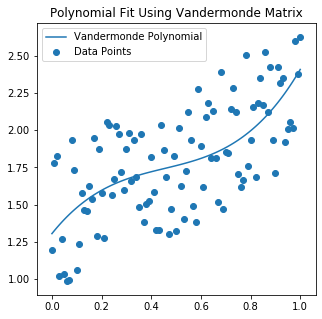

In [4]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ------------------------------------------------------------
# PART A
# Linear Least Squares vs Cubic Polynomial Fit
# ------------------------------------------------------------

# Create X values
X1 = np.arange(0, 1.01, .01)

# Create a random linear function y = mx + b
m = np.random.rand()
b = np.random.rand()

# Add noise so the data is not perfectly linear
Y = m*X1 + b + np.random.rand(X1.size)

print("Random Slope:", m)
print("Random Intercept:", b)

# -----------------------------
# Linear Least Squares Method
# -----------------------------
# Build matrix for Ax = b form
B = np.vstack([X1, np.ones(len(X1))]).T

# Solve for slope and intercept using Least Squares
n, d = np.linalg.lstsq(B, Y, rcond=None)[0]

# Predicted values from Least Squares
Y_linear = n*X1 + d


# -----------------------------
# Cubic Polynomial Fit
# -----------------------------
# Fit a cubic polynomial (degree = 3)
coeffs = np.polyfit(X1, Y, 3)

# Evaluate the polynomial
Y_poly = np.polyval(coeffs, X1)



# Mean Squared Error (MSE)
mse_linear = np.mean((Y - Y_linear)**2)
mse_poly = np.mean((Y - Y_poly)**2)

# Total variance in data (needed for R^2)
ss_tot = np.sum((Y - np.mean(Y))**2)

# R-Squared
r2_linear = 1 - (np.sum((Y-Y_linear)**2) / ss_tot)
r2_poly = 1 - (np.sum((Y-Y_poly)**2) / ss_tot)


print("\nLinear Least Squares Fit")
print("MSE:", mse_linear)
print("R^2:", r2_linear)

print("\nCubic Polynomial Fit")
print("MSE:", mse_poly)
print("R^2:", r2_poly)


# -----------------------------
# Determine Better Model
# -----------------------------
# Lower MSE and higher R^2 indicate a better model

if mse_linear < mse_poly and r2_linear > r2_poly:
    print("\nLinear model is the better fit")
else:
    print("\nPolynomial model is the better fit")


# -----------------------------
# Plot Results
# -----------------------------
plt.figure(figsize=(5,5))
plt.title("Linear Least Squares vs Cubic Polynomial Fit")

plt.scatter(X1, Y, label="Data Points")
plt.plot(X1, Y_linear, label="Least Squares Line")
plt.plot(X1, Y_poly, label="Cubic Polynomial")

plt.legend()
plt.show()



# ------------------------------------------------------------
# PART B
# Increasing and Decreasing Polynomial Degree
# ------------------------------------------------------------

print("\nTesting Polynomial Degrees to show underfitting and overfitting\n")

# We increase polynomial degree gradually
# Small degree -> UNDERFITTING
# Large degree -> OVERFITTING

for degree in range(1,10):

    coeffs = np.polyfit(X1, Y, degree)
    Y_poly = np.polyval(coeffs, X1)

    # MSE
    mse = np.mean((Y - Y_poly)**2)

    # R^2
    ss_tot = np.sum((Y - np.mean(Y))**2)
    r2 = 1 - (np.sum((Y-Y_poly)**2)/ss_tot)

    print("Polynomial Degree:", degree)
    print("MSE:", mse)
    print("R^2:", r2)

    # Comments describing fitting behavior
    if degree == 1:
        print("Likely UNDERFITTING (too simple)")
    elif degree >= 7:
        print("Likely OVERFITTING (model becoming too complex)")
    
    print()


# ------------------------------------------------------------
# PART C
# Polynomial Fit using the Vandermonde Matrix
# ------------------------------------------------------------

degree = 3

# Build Vandermonde matrix
# Each column corresponds to x^n terms
V = np.vander(X1, degree+1)

# Solve Least Squares using Vandermonde matrix
coefficients = np.linalg.lstsq(V, Y, rcond=None)[0]

# Create polynomial function from coefficients
# np.poly1d expects highest degree first, which matches np.vander
polynomial = np.poly1d(coefficients)

# Evaluate polynomial
Y_vander = polynomial(X1)


# -----------------------------
# Error Metrics
# -----------------------------

mse_vander = np.mean((Y - Y_vander)**2)

ss_tot = np.sum((Y - np.mean(Y))**2)
r2_vander = 1 - (np.sum((Y-Y_vander)**2)/ss_tot)


print("\nVandermonde Polynomial Fit (Degree 3)")
print("MSE:", mse_vander)
print("R^2:", r2_vander)


# -----------------------------
# Plot Vandermonde Fit
# -----------------------------

plt.figure(figsize=(5,5))
plt.title("Polynomial Fit Using Vandermonde Matrix")

plt.scatter(X1, Y, label="Data Points")
plt.plot(X1, Y_vander, label="Vandermonde Polynomial")

plt.legend()
plt.show()

In [2]:
# --- PART B ---

print("\nTesting Polynomial Degrees\n")

for degree in range(1,10):

    coeffs = np.polyfit(X1, Y, degree)
    Y_poly = np.polyval(coeffs, X1)

    mse = np.mean((Y - Y_poly)**2)

    ss_tot = np.sum((Y - np.mean(Y))**2)
    r2 = 1 - (np.sum((Y-Y_poly)**2)/ss_tot)

    print("Degree:", degree)
    print("MSE:", mse)
    print("R^2:", r2)
    print()


Testing Polynomial Degrees

Degree: 1
MSE: 0.08824196322481227
R^2: 0.28589322434736786

Degree: 2
MSE: 0.08706672741254322
R^2: 0.2954039358712358

Degree: 3
MSE: 0.08650236155732195
R^2: 0.29997112212177

Degree: 4
MSE: 0.08602412925479488
R^2: 0.3038412641164634

Degree: 5
MSE: 0.08602411855437728
R^2: 0.30384135071064644

Degree: 6
MSE: 0.08442833233270657
R^2: 0.31675540782976264

Degree: 7
MSE: 0.07959702885719346
R^2: 0.35585320689287225

Degree: 8
MSE: 0.07852231297675892
R^2: 0.3645504509712314

Degree: 9
MSE: 0.07834490561179773
R^2: 0.36598613753961284



Vandermonde Polynomial Fit (Degree 3)
MSE: 0.08650236155732195
R^2: 0.29997112212177


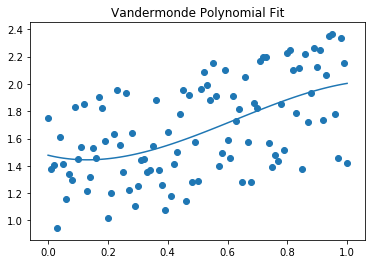

In [3]:
# --- PART C ---#

degree = 3

V = np.vander(X1, degree+1)

coefficients = np.linalg.lstsq(V, Y, rcond=None)[0]

# FIX: reverse coefficient order
polynomial = np.poly1d(coefficients)

Y_vander = polynomial(X1)

mse_vander = np.mean((Y - Y_vander)**2)

ss_tot = np.sum((Y - np.mean(Y))**2)
r2_vander = 1 - (np.sum((Y-Y_vander)**2)/ss_tot)

print("Vandermonde Polynomial Fit (Degree 3)")
print("MSE:", mse_vander)
print("R^2:", r2_vander)

plt.title("Vandermonde Polynomial Fit")
plt.scatter(X1, Y)
plt.plot(X1, Y_vander)
plt.show()